## Time-dependent problems: the diffusion equation

Lectures 1 to 3 dealt with stationary problems. Now the solution changes in time, and the simplest example is the
one-dimensional diffusion (heat) equation on $\Omega = (0, 1)$,

$$\frac{\partial u}{\partial t} = \kappa\, \frac{\partial^2 u}{\partial x^2} + f \qquad \text{for } t > 0,
  \qquad u(x, 0) = u_0(x),$$

with the diffusivity $\kappa$, a source $f$, boundary conditions as in the Laplace example of lecture 1
(temperature prescribed: Dirichlet; flux $q \cdot n = g$ with $q = -\kappa\, u'$ prescribed: Neumann) and, new,
an **initial condition** $u_0$.

### Semi-discretisation in space

Multiplying by a test function $v$ (with $v = 0$ on the Dirichlet boundary), integrating and integrating the
diffusion term by parts once gives, exactly as in lecture 1,

$$\int_0^1 \frac{\partial u}{\partial t}\, v \, dx + \kappa \int_0^1 u'\, v' \, dx
  = \int_0^1 f\, v \, dx - \int_\Gamma g\, v \, ds \qquad \text{for all } v .$$

The finite element approximation $u_h(x, t) = \sum_j U_j(t)\, \varphi_j(x)$ now has **time-dependent
coefficients**. Inserting it and testing with $v = \varphi_i$ turns the partial differential equation into a system
of ordinary differential equations for the vector $U(t)$, the **semi-discrete system**

$$M\, \dot U + K\, U = F, \qquad
  M_{ij} = \int_0^1 \varphi_i\, \varphi_j \, dx, \qquad
  K_{ij} = \kappa \int_0^1 \varphi_i'\, \varphi_j' \, dx, \qquad
  F_i = \int_0^1 f\, \varphi_i \, dx - \int_\Gamma g\, \varphi_i \, ds .$$

$K$ is the stiffness matrix of lecture 1. The **mass matrix** $M$ is new: it comes from the time derivative,
it is symmetric and positive definite, and it couples neighbouring nodes ($M$ is tridiagonal for P1 elements),
which will matter below.

### Forward and backward Euler, Crank–Nicolson

For a system $\dot U = G(U)$ the two Euler methods are known: with the time step $\Delta t$ and
$U^n \approx U(t_n)$, $t_n = n\, \Delta t$,

$$\text{forward (explicit): } \frac{U^{n+1} - U^n}{\Delta t} = G(U^n), \qquad\qquad
  \text{backward (implicit): } \frac{U^{n+1} - U^n}{\Delta t} = G(U^{n+1}) .$$

Both are contained in the **$\theta$-method**, which evaluates the right-hand side at the intermediate state
$\theta\, U^{n+1} + (1 - \theta)\, U^n$. For the semi-discrete system $M \dot U = F - K U$ this gives

$$\big(M + \theta\, \Delta t\, K\big)\, U^{n+1} = \big(M - (1 - \theta)\, \Delta t\, K\big)\, U^n + \Delta t\, F ,$$

a linear system per time step, with $\theta = 0$ (forward Euler), $\theta = 1$ (backward Euler) and
$\theta = \tfrac12$ (**Crank–Nicolson**, the average of the two, i.e. the trapezoidal rule).

**In the variational language** the same reads: find $u^{n+1}$ such that for all $v$

$$\int_0^1 u^{n+1} v \, dx + \theta\, \Delta t\, \kappa \int_0^1 (u^{n+1})'\, v' \, dx
  = \int_0^1 u^n v \, dx - (1 - \theta)\, \Delta t\, \kappa \int_0^1 (u^n)'\, v' \, dx
    + \Delta t \int_0^1 f\, v \, dx - \Delta t \int_\Gamma g\, v \, ds .$$

Compared with lecture 1, the **bilinear form** $a(u, v)$ gets the mass term $\int u v \, dx$ and the factor
$\theta \Delta t \kappa$ in front of the stiffness term, and the **linear form** $L(v)$ gets the previous time
level $u^n$, a known `Function`, not a `TrialFunction`. In FEniCS:

```python
a = u*v*dx + theta*dt*kappa*inner(grad(u), grad(v))*dx
L = u_n*v*dx - (1 - theta)*dt*kappa*inner(grad(u_n), grad(v))*dx + dt*f*v*dx
for n in range(nr_steps):
    solve(a == L, u, bc)
    u_n.assign(u)
```

Things to look out for:

- **Even forward Euler needs a linear solve**, with the mass matrix: $M U^{n+1} = (M - \Delta t K) U^n + \Delta t F$.
  The method becomes truly explicit only if $M$ is replaced by a diagonal matrix, the **lumped mass matrix**
  $M_L$ with the row sums of $M$ on the diagonal (for P1 elements $h$ at the inner nodes and $h/2$ at the ends).
- **Stability.** Forward Euler is stable only for $\Delta t \le 2 / \lambda_{\max}$, where $\lambda_{\max}$ is the
  largest eigenvalue of $M^{-1} K$. For P1 elements on a uniform mesh $\lambda_{\max} \approx 4\kappa / h^2$ with the
  lumped and $12\kappa / h^2$ with the consistent mass matrix (exercise 1), hence
  $$\Delta t \le \frac{h^2}{2\kappa} \; (\text{lumped mass}), \qquad \Delta t \le \frac{h^2}{6\kappa} \; (\text{consistent mass}) .$$
  Halving $h$ quarters the admissible time step. Backward Euler and Crank–Nicolson are stable for every $\Delta t$.
- **Accuracy.** The Euler methods are first order in time, $O(\Delta t)$, Crank–Nicolson is second order, $O(\Delta t^2)$.
  Crank–Nicolson, however, damps the fast modes only weakly (its amplification factor tends to $-1$ for
  $\Delta t\, \lambda \to \infty$): with initial data that do not match the boundary values, such as $u_0 = 0$ and $u(1) = 1$,
  it produces oscillations near $x = 1$ during the first steps, which backward Euler damps away immediately.
- The Dirichlet values have to be applied in every step (they may depend on time), and the initial condition is
  interpolated into the finite element space, `u_n = interpolate(u_0, V)`.

In [1]:
from fenics import *
from matplotlib import pyplot
import matplotlib.tri
import numpy as np
import scipy.linalg
import wave
%matplotlib inline

set_log_level(LogLevel.WARNING)   # silence the solver messages ...
import logging
logging.getLogger('FFC').setLevel(logging.WARNING)   # ... and those of the JIT compiler

### The $\theta$-method in FEniCS

`solve_heat` runs the $\theta$-method from $t = 0$ to $T$ for the mesh of lecture 1 and returns the final solution
together with snapshots at requested steps. `forward_euler_lumped` is the explicit alternative: it assembles $K$
and the lumped mass matrix once and updates the coefficient vector directly, without any linear solve.

In [2]:
tol = 1e-3

def left(x, on_boundary):
    return on_boundary and near(x[0], 0.0, tol)

def right(x, on_boundary):
    return on_boundary and near(x[0], 1.0, tol)

def solve_heat(V, u_0, T, dt, theta, kappa=1.0, f=Constant(0.0), g=None, bcs=[], snapshots=()):
    # theta-method from t = 0 to T; returns u(T) and the snapshots {step: u} asked for
    u_n = interpolate(u_0, V)
    u, v = TrialFunction(V), TestFunction(V)
    th, k = Constant(theta), Constant(dt)      # as Constants: the forms are compiled only once
    a = u*v*dx + th*k*kappa*inner(grad(u), grad(v))*dx
    L = u_n*v*dx - (1 - th)*k*kappa*inner(grad(u_n), grad(v))*dx + k*f*v*dx
    if g is not None:
        L = L - k*g*v*ds
    u = Function(V)
    out = {}
    for n in range(1, int(round(T/dt)) + 1):
        solve(a == L, u, bcs)
        u_n.assign(u)
        if n in snapshots:
            out[n] = u.copy(deepcopy=True)
    return u_n, out

def forward_euler_lumped(V, u_0, T, dt, kappa=1.0, f=Constant(0.0), bcs=[]):
    # explicit update with the lumped mass matrix (row sums of M): no linear system to solve
    u, v = TrialFunction(V), TestFunction(V)
    K   = assemble(kappa*inner(grad(u), grad(v))*dx).array()
    M_L = assemble(u*v*dx).array().sum(axis=1)
    F   = assemble(f*v*dx).get_local()
    U   = interpolate(u_0, V).vector().get_local()
    fixed = {}
    for bc in bcs:
        fixed.update(bc.get_boundary_values())
    for n in range(int(round(T/dt))):
        U = U + dt*(F - K @ U)/M_L
        for i, value in fixed.items():
            U[i] = value
    u = Function(V)
    u.vector()[:] = U
    return u

### 1. The three problems of lecture 1, now time-dependent

The three boundary value problems of lecture 1 (20 P1 elements, $\kappa = 1$), all started from $u_0 = 0$ and
integrated with backward Euler, $\Delta t = 0.01$: the temperature fixed at both ends, the heated rod with an
insulated end, and the rod heated through the end. In each case the solution approaches the steady state computed
in lecture 1 ($u = x$, $u = x - \tfrac12 x^2$, $u = x$), which is reached exactly by backward Euler for any
$\Delta t$, because the steady state satisfies $(M + \Delta t K) U = M U + \Delta t F$.

The deviation from the steady state decays exponentially, with the slowest mode of the problem: $e^{-\pi^2 t}$ for
problem 1 and $e^{-\pi^2 t / 4}$ for problems 2 and 3 (exercise 2), so the insulated end makes the transient four
times longer. Backward Euler damps a little too slowly, its first-order error: the deviation of problem 3 at
$t = 1$ is 3 % larger than the exact first mode.

1. Dirichlet - Dirichlet             max |u - steady state|:  t = 1: 5.1e-05   t = 3: 3.2e-13
2. Dirichlet - homogeneous Neumann   max |u - steady state|:  t = 1: 4.5e-02   t = 3: 3.4e-04


3. Dirichlet - Neumann               max |u - steady state|:  t = 1: 7.1e-02   t = 3: 5.4e-04
first mode of the transient of problem 3 at t = 1:  8/pi^2 exp(-pi^2/4) = 6.9e-02


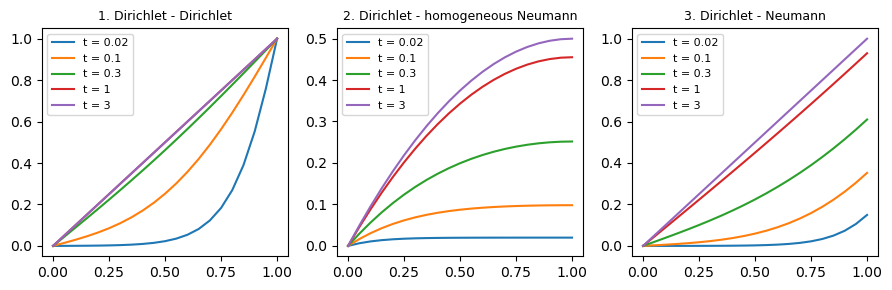

In [3]:
mesh = IntervalMesh(20, 0.0, 1.0)
V = FunctionSpace(mesh, 'Lagrange', 1)
xk = V.tabulate_dof_coordinates().flatten()      # node coordinates, for the comparison with the steady states

dt, T = 0.01, 3.0
snapshots = (2, 10, 30, 100, 300)                # t = 0.02, 0.1, 0.3, 1, 3
problems = [("1. Dirichlet - Dirichlet",
             dict(bcs=[DirichletBC(V, Constant(0.0), left), DirichletBC(V, Constant(1.0), right)]), xk),
            ("2. Dirichlet - homogeneous Neumann",
             dict(bcs=[DirichletBC(V, Constant(0.0), left)], f=Constant(1.0)), xk - 0.5*xk**2),
            ("3. Dirichlet - Neumann",
             dict(bcs=[DirichletBC(V, Constant(0.0), left)], g=Constant(-1.0)), xk)]

pyplot.figure(figsize=(9, 3), dpi=100)
for i, (title, data, u_steady) in enumerate(problems):
    u_T, out = solve_heat(V, Constant(0.0), T, dt, theta=1.0, snapshots=snapshots, **data)
    print("%-36s max |u - steady state|:  t = 1: %.1e   t = 3: %.1e"
          % (title, abs(out[100].vector().get_local() - u_steady).max(), abs(u_T.vector().get_local() - u_steady).max()))
    pyplot.subplot(1, 3, i + 1)
    for n in snapshots:
        plot(out[n])
    pyplot.autoscale()
    pyplot.legend(["t = %g" % (n*dt) for n in snapshots], fontsize=8)
    pyplot.title(title, fontsize=9)
pyplot.tight_layout()
pyplot.savefig("diffusion-0.png")
print("first mode of the transient of problem 3 at t = 1:  8/pi^2 exp(-pi^2/4) = %.1e" % (8/np.pi**2*np.exp(-np.pi**2/4)))

### 2. Stability of forward Euler

Initial condition $u_0 = \sin(\pi x)$, $u = 0$ at both ends, $f = 0$, $\kappa = 1$: the exact solution is
$u = \sin(\pi x)\, e^{-\pi^2 t}$. With $h = 1/20$ the limits are $\Delta t \le h^2/6 = 4.2 \cdot 10^{-4}$ for the
consistent and $\Delta t \le h^2/2 = 1.25 \cdot 10^{-3}$ for the lumped mass matrix. Four runs to $T = 0.1$, one
on each side of each limit. The unstable runs start from round-off errors: the fastest mode, the checkerboard
$(-1)^i$, is amplified by $|1 - \Delta t\, \lambda_{\max}|$ in every step, and after a few hundred steps it
dominates the solution.

stability limits: consistent mass h^2/6 = 4.17e-04,  lumped mass h^2/2 = 1.25e-03
consistent mass, dt = 4.0e-04:  max |u(T)| =  3.712e-01   (exact 3.727e-01)
consistent mass, dt = 5.0e-04:  max |u(T)| =  8.687e+09   (exact 3.727e-01)


lumped     mass, dt = 1.0e-03:  max |u(T)| =  3.716e-01   (exact 3.727e-01)
lumped     mass, dt = 2.0e-03:  max |u(T)| =  5.551e+00   (exact 3.727e-01)


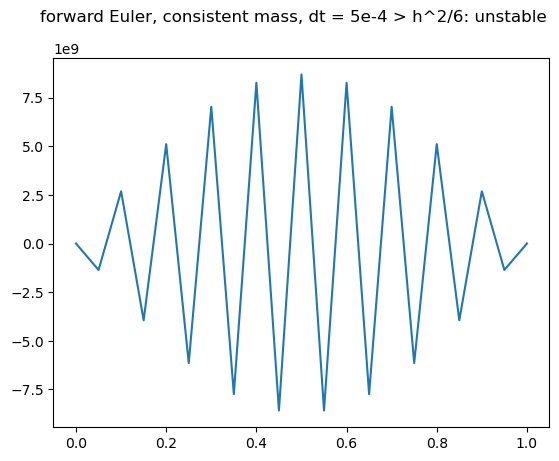

In [4]:
u_sin = Expression("sin(pi*x[0])", degree=4)
u_ex  = Expression("sin(pi*x[0])*exp(-pi*pi*kappa*t)", degree=4, kappa=1.0, t=0.0)
bcs0  = [DirichletBC(V, Constant(0.0), left), DirichletBC(V, Constant(0.0), right)]
h = 1.0/20
T = 0.1
print("stability limits: consistent mass h^2/6 = %.2e,  lumped mass h^2/2 = %.2e" % (h**2/6, h**2/2))
for mass, dt in [("consistent", 4e-4), ("consistent", 5e-4), ("lumped", 1e-3), ("lumped", 2e-3)]:
    if mass == "consistent":
        u_T, _ = solve_heat(V, u_sin, T, dt, theta=0.0, bcs=bcs0)
    else:
        u_T = forward_euler_lumped(V, u_sin, T, dt, bcs=bcs0)
    print("%-10s mass, dt = %.1e:  max |u(T)| = %10.3e   (exact %.3e)"
          % (mass, dt, abs(u_T.vector().get_local()).max(), np.exp(-np.pi**2*T)))
    if (mass, dt) == ("consistent", 5e-4):
        u_unstable = u_T

pyplot.figure(dpi=100)
plot(u_unstable)
pyplot.suptitle("forward Euler, consistent mass, dt = 5e-4 > h^2/6: unstable")
pyplot.savefig("diffusion-1.png")

### 3. Accuracy: backward Euler against Crank–Nicolson

The same problem on 200 elements (so that the spatial error stays small), integrated to $T = 0.1$ with
$\Delta t = T/2, \dots, T/64$; the $L^2$ error against the exact solution and the observed order
$\log_2(e_{\Delta t} / e_{\Delta t / 2})$. Backward Euler halves its error with the time step, Crank–Nicolson
quarters it, until its error reaches the spatial discretisation error of about $10^{-5}$, which no time step can
reduce: two independent sources of error, and it is pointless to push one far below the other.

In [5]:
mesh_fine = IntervalMesh(200, 0.0, 1.0)
V_fine    = FunctionSpace(mesh_fine, 'Lagrange', 1)
bcs_fine  = [DirichletBC(V_fine, Constant(0.0), left), DirichletBC(V_fine, Constant(0.0), right)]
T = 0.1
u_ex.t = T
errors = {1.0: [], 0.5: []}
order  = lambda e: "%.2f" % np.log2(e[-2]/e[-1]) if len(e) > 1 else "    "
print("        dt   backward Euler  order   Crank-Nicolson  order")
for k in range(1, 7):
    dt = T/2**k
    for theta in errors:
        u_T, _ = solve_heat(V_fine, u_sin, T, dt, theta, bcs=bcs_fine)
        errors[theta].append(errornorm(u_ex, u_T, 'L2'))
    print("%10.5f     %.2e      %s      %.2e     %s" % (dt, errors[1.0][-1], order(errors[1.0]), errors[0.5][-1], order(errors[0.5])))

        dt   backward Euler  order   Crank-Nicolson  order


   0.05000     5.35e-02                5.43e-03         
   0.02500     2.91e-02      0.88      1.34e-03     2.02
   0.01250     1.53e-02      0.93      3.41e-04     1.97
   0.00625     7.81e-03      0.97      9.33e-05     1.87
   0.00313     3.95e-03      0.98      3.15e-05     1.57
   0.00156     1.98e-03      0.99      1.61e-05     0.97


## Mode superposition

### Elastodynamics: the semi-discrete system

For an elastic body the time enters through the inertia: Newton's second law per unit volume,
$\rho\, \ddot u = \nabla \cdot \sigma(u) + f$. Multiplying by $v$, integrating and integrating by parts as in
lecture 2 gives the weak form

$$\int_\Omega \rho\, \ddot u \cdot v \; dx + \int_\Omega \sigma(u) : \varepsilon(v) \; dx
  = \int_\Omega f \cdot v \; dx + \int_\Gamma T \cdot v \; ds \qquad \text{for all } v ,$$

and with $u_h = \sum_j U_j(t)\, \varphi_j$ the semi-discrete system

$$M\, \ddot U + K\, U = F, \qquad M_{ij} = \int_\Omega \rho\, \varphi_i \cdot \varphi_j \; dx ,$$

with the stiffness matrix $K$ of lecture 2 and the mass matrix $M$, now with the density $\rho$. It is of second
order in time (oscillations instead of decay), and it could be integrated step by step like the diffusion equation
(the Newmark method in example 5 does that). Mode superposition takes a different route.

### The eigenvalue problem

Free vibrations, $F = 0$, of the form $U(t) = \varphi\, \cos(\omega t)$ require $-\omega^2 M \varphi + K \varphi = 0$,
the **generalized eigenvalue problem**

$$K\, \varphi_k = \omega_k^2\, M\, \varphi_k, \qquad k = 1, \dots, N .$$

The same kind of generalized eigenvalue problem appeared in lecture 3 for buckling, with the geometric stiffness
matrix in place of the mass matrix. Because $K$ and $M$ are symmetric and $M$ is positive definite, the eigenvalues
are real and non-negative, the $\omega_k$ are the **eigenfrequencies**, and the eigenvectors, the **modes**
$\varphi_k$, can be chosen $M$-orthonormal:

$$\varphi_k^T M \varphi_l = \delta_{kl}, \qquad \varphi_k^T K \varphi_l = \omega_k^2\, \delta_{kl} .$$

Dirichlet conditions ($u = 0$ on the clamped end) are built in by removing the constrained degrees of freedom
from $K$ and $M$ (or, equivalently, by clearing their rows and columns, as in the tuning fork below).

### Decoupling: modal coordinates

Write the solution as a superposition of modes with time-dependent amplitudes, the **modal coordinates** $q_k(t)$,

$$U(t) = \sum_k q_k(t)\, \varphi_k = \Phi\, q(t), \qquad q_k = \varphi_k^T M\, U ,$$

insert into $M \ddot U + K U = F$ and multiply by $\varphi_k^T$. The orthogonality relations kill all cross terms,
and what remains are $N$ **decoupled scalar oscillators**

$$\ddot q_k + \omega_k^2\, q_k = f_k(t) := \varphi_k^T F(t) .$$

The degrees of freedom of the body have been totally decoupled: each mode swings on its own, with the analytic
solution (free vibration, $f_k = 0$)

$$q_k(t) = q_k(0) \cos(\omega_k t) + \frac{\dot q_k(0)}{\omega_k} \sin(\omega_k t),
  \qquad q_k(0) = \varphi_k^T M\, U(0), \quad \dot q_k(0) = \varphi_k^T M\, \dot U(0) ,$$

exact in time, without time step and without stability limit. In practice one keeps only the lowest $m \ll N$
modes: smooth initial data and loads are represented by a few modes (exercise 3), and these are also the modes a
structure responds with; the higher ones are damped away in reality.

### Modes and the Fourier transform

On a uniform grid on an interval (or a box) with $u = 0$ at the ends the modes are the sampled sine functions,
$\varphi_k(x_j) = \sin(k \pi x_j)$, and the modal transform $q = \Phi^T M U$ is a discrete sine (Fourier)
transform: mode superposition is then the Fourier method for the wave and heat equations, and the transform costs
$O(N \log N)$ operations with the **fast Fourier transform**. For a finite element mesh on an arbitrary geometry
nothing of this survives: the modes are not known in closed form, they have to be computed numerically, each of
them is a dense vector, and the transform is a dense matrix-vector product. There is no fast Fourier transform for
finite elements. That is why one computes only a few of the lowest modes with an iterative eigenvalue solver
(SLEPc, below) and accepts the truncation, instead of transforming everything.

### 4. Eigenfrequencies and modes of the cantilever

The plane-strain cantilever of lecture 2, examples 3 to 5 ($E = 1000$, $\nu = 0.3$, $L = 5$, $H = 1$, 50 × 10 P1
elements), with the density $\rho = 1$; the own weight $\rho g = 0.3$ of lecture 2 then means $g = 0.3$. The problem
is small (1100 free degrees of freedom), so all modes are computed at once with `scipy.linalg.eigh`, which returns
them $M$-orthonormal; the constrained degrees of freedom are removed from the matrices. For comparison, the
Euler–Bernoulli cantilever has $\omega_n = (\beta_n L)^2 / L^2 \cdot \sqrt{E' I / (\rho A)}$ with
$\beta_n L = 1.875,\ 4.694,\ 7.855$, $E' = E/(1 - \nu^2)$ (plane strain), $I = H^3 / 12$, $A = H$, and the first
axial mode is $\omega = \pi / (2L) \cdot \sqrt{E' / \rho}$. The first bending frequency is 1 % below the beam value,
the second 15 %: for $L / H = 5$ shear deformation and rotary inertia, which the beam theory neglects, soften the
higher modes noticeably. The lowest eigenvalues are checked against SLEPc, the iterative solver that computes
only the modes asked for and that the tuning fork below needs.

In [6]:
length, height = 5.0, 1.0
E, nu, rho = 1000.0, 0.3, 1.0
rho_g = 0.3
nr_elements = 10   # per unit length

mesh = RectangleMesh(Point(0.0, 0.0), Point(length, height), int(length*nr_elements), int(height*nr_elements))
V = VectorFunctionSpace(mesh, 'Lagrange', 1)

# material law of lecture 2: strain energy in terms of the bulk and the shear modulus, stress by differentiation
K_bulk  = E/(3*(1 - 2*nu))
G_shear = E/(2*(1 + nu))

def epsilon(u):
    return sym(grad(u))

def psi(eps):
    return 0.5*K_bulk*tr(eps)**2 + G_shear*(inner(eps, eps) - tr(eps)**2/3)

def sigma(u):
    eps = variable(epsilon(u))
    return diff(psi(eps), eps)

bc = DirichletBC(V, Constant((0.0, 0.0)), left)

# stiffness and mass matrix as dense arrays, restricted to the free degrees of freedom
du, v = TrialFunction(V), TestFunction(V)
K = assemble(inner(sigma(du), epsilon(v))*dx).array()
M = assemble(rho*inner(du, v)*dx).array()
fixed = np.array(sorted(bc.get_boundary_values().keys()))
free  = np.setdiff1d(np.arange(V.dim()), fixed)
K_f, M_f = K[np.ix_(free, free)], M[np.ix_(free, free)]

# all eigenpairs of K phi = omega^2 M phi, eigenvectors M-orthonormal
lam, Phi = scipy.linalg.eigh(K_f, M_f)
omega = np.sqrt(lam)
print("%d free degrees of freedom, %d modes" % (len(free), len(omega)))
print("orthogonality: max |Phi^T M Phi - I| = %.1e,  max |Phi^T K Phi - diag(omega^2)| = %.1e"
      % (abs(Phi.T @ M_f @ Phi - np.eye(len(free))).max(), abs(Phi.T @ K_f @ Phi - np.diag(lam)).max()))

# beam theory: bending modes of the clamped cantilever and the first axial mode, plane strain
E_p = E/(1 - nu**2)
I, A = height**3/12, height
omega_bend  = np.array([1.8751, 4.6941, 7.8548])**2/length**2*np.sqrt(E_p*I/(rho*A))
omega_axial = np.pi/(2*length)*np.sqrt(E_p/rho)
print("omega FEM, modes 1-6:   " + "  ".join("%7.3f" % w for w in omega[:6]))
print("beam theory, bending:   " + "  ".join("%7.3f" % w for w in omega_bend) + "   (modes 1, 2 and 4)")
print("beam theory, axial:      %7.3f   (mode 3)" % omega_axial)

1100 free degrees of freedom, 1100 modes
orthogonality: max |Phi^T M Phi - I| = 2.9e-15,  max |Phi^T K Phi - diag(omega^2)| = 5.6e-09
omega FEM, modes 1-6:     1.334    7.137   10.467   16.934   28.092   31.232
beam theory, bending:     1.346    8.434   23.617   (modes 1, 2 and 4)
beam theory, axial:       10.414   (mode 3)


omega SLEPc, modes 1-6:   1.334    7.137   10.467   16.934   28.092   31.232


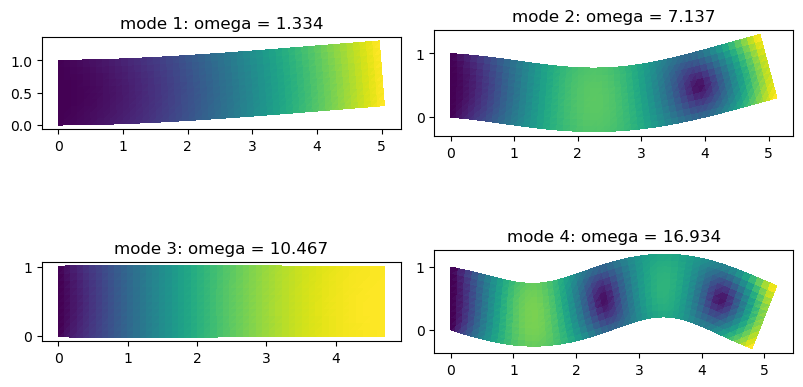

In [7]:
# the same lowest eigenvalues with SLEPc: rows and columns of the constrained dofs are cleared, with 1 on the
# diagonal of K and 0 on that of M, so that these dofs get omega = infinity and never show up among the lowest modes
K_p, M_p = PETScMatrix(), PETScMatrix()
assemble(inner(sigma(du), epsilon(v))*dx, tensor=K_p)
assemble(rho*inner(du, v)*dx, tensor=M_p)
K_p.mat().zeroRowsColumns(fixed.astype(np.int32), diag=1.0)
M_p.mat().zeroRowsColumns(fixed.astype(np.int32), diag=0.0)

solver = SLEPcEigenSolver(K_p, M_p)
solver.parameters['problem_type']       = 'gen_hermitian'
solver.parameters['spectral_transform'] = 'shift-and-invert'
solver.parameters['spectral_shift']     = 0.0
solver.parameters['spectrum']           = 'target magnitude'
solver.parameters['tolerance']          = 1e-12
solver.solve(6)
print("omega SLEPc, modes 1-6: " + "  ".join("%7.3f" % np.sqrt(solver.get_eigenpair(k)[0]) for k in range(6)))

def mode_function(k, scale=0.3):
    # mode k as a Function on the full space, scaled for plotting
    phi = Function(V)
    values = np.zeros(V.dim())
    values[free] = Phi[:, k]
    phi.vector()[:] = scale/abs(values).max()*values
    return phi

pyplot.figure(figsize=(8, 5), dpi=100)
for k in range(4):
    pyplot.subplot(2, 2, k + 1)
    plot(mode_function(k), mode='displacement', title='mode %d: omega = %.3f' % (k + 1, omega[k]))
pyplot.tight_layout()
pyplot.savefig("modes-0.png")

### 5. The swinging beam

The cantilever is bent by its own weight (example 4 of lecture 2), then released: initial displacement $U(0) = U_0$,
the static deflection, initial velocity zero, no load. The modal coordinates $q_k(0) = \varphi_k^T M U_0$ tell how
much of the initial shape each mode carries; almost everything sits in the first mode, whose shape resembles the
static deflection. The vertical displacement of the tip is then a sum of cosines, $u_{\text{tip}}(t) = \sum_k q_k(0)\,
\varphi_{k, \text{tip}} \cos(\omega_k t)$, evaluated with 1, 3 and all modes.

For comparison, $M \ddot U + K U = 0$ is also integrated step by step with the **Newmark method** (average
acceleration, $\beta = \tfrac14$, $\gamma = \tfrac12$: unconditionally stable, second order, the trapezoidal rule of
the second-order system). Its period error, $(\omega \Delta t)^2 / 12$ per period, is negligible for the first mode
but not for the higher ones, whose periods are much shorter: with $\Delta t = T_1 / 50$ the second mode has drifted
out of phase after a few periods, and the curve deviates visibly from the exact mode superposition. That is the
point of mode superposition: each mode is integrated exactly, however fast it is.

strain energy of the initial deflection 0.07850;  in modes 1, 2, 3:  0.07753  0.00091  0.00000
period of the first mode T_1 = 4.708
tip displacement at t = 0:  static -0.25497,  1 mode -0.25934,  3 modes -0.25460,  10 modes -0.25496
Newmark, dt = T_1/50 : max |Newmark - all modes| = 1.5e-02


Newmark, dt = T_1/200: max |Newmark - all modes| = 2.1e-03


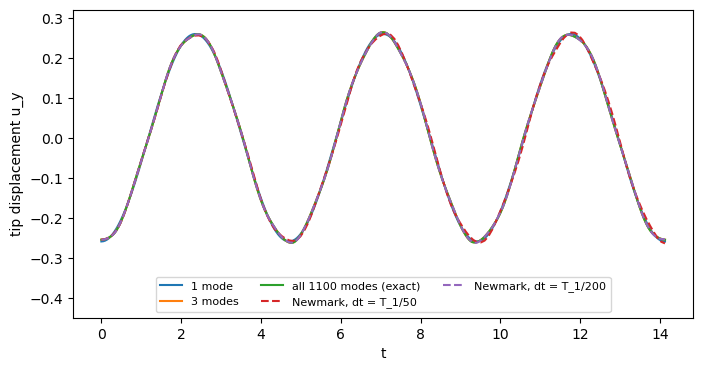

In [8]:
# initial displacement: the static deflection under the own weight (example 4 of lecture 2)
u_static = Function(V)
Pi = ( psi(epsilon(u_static)) - dot(Constant((0.0, -rho_g)), u_static) )*dx
solve(derivative(Pi, u_static, v) == 0, u_static, bc)
U_0 = u_static.vector().get_local()[free]

q_0 = Phi.T @ (M_f @ U_0)                         # modal coordinates of the initial displacement
print("strain energy of the initial deflection %.5f;  in modes 1, 2, 3:  %s"
      % (0.5*U_0 @ K_f @ U_0, "  ".join("%.5f" % e for e in 0.5*lam[:3]*q_0[:3]**2)))

# vertical tip displacement (L, H/2) over time from the first m modes
coords = V.tabulate_dof_coordinates().reshape(-1, 2)
dofs_y = np.array(V.sub(1).dofmap().dofs())
tip = np.where(free == dofs_y[np.argmin(np.hypot(coords[dofs_y, 0] - length, coords[dofs_y, 1] - height/2))])[0][0]

def tip_modal(t, m):
    return (Phi[tip, :m]*q_0[:m]) @ np.cos(np.outer(omega[:m], t))

T_1 = 2*np.pi/omega[0]
print("period of the first mode T_1 = %.3f" % T_1)
print("tip displacement at t = 0:  static %.5f,  1 mode %.5f,  3 modes %.5f,  10 modes %.5f"
      % (U_0[tip], tip_modal(0.0, 1)[0], tip_modal(0.0, 3)[0], tip_modal(0.0, 10)[0]))

def newmark(dt, nr_steps, beta=0.25, gamma=0.5):
    # average acceleration method for M u'' + K u = 0 with u(0) = U_0, u'(0) = 0; returns the times and the tip displacement
    lu = scipy.linalg.lu_factor(M_f + beta*dt**2*K_f)
    u, vel = U_0.copy(), np.zeros_like(U_0)
    acc = scipy.linalg.solve(M_f, -K_f @ u, assume_a='pos')
    tips = [u[tip]]
    for n in range(nr_steps):
        u_pred   = u + dt*vel + 0.5*dt**2*(1 - 2*beta)*acc
        vel_pred = vel + dt*(1 - gamma)*acc
        acc = scipy.linalg.lu_solve(lu, -K_f @ u_pred)
        u   = u_pred + beta*dt**2*acc
        vel = vel_pred + gamma*dt*acc
        tips.append(u[tip])
    return dt*np.arange(nr_steps + 1), np.array(tips)

tt = np.linspace(0.0, 3*T_1, 601)
pyplot.figure(figsize=(8, 4), dpi=100)
for m, label in [(1, "1 mode"), (3, "3 modes"), (len(free), "all %d modes (exact)" % len(free))]:
    pyplot.plot(tt, tip_modal(tt, m), label=label)
for steps_per_period in (50, 200):
    dt = T_1/steps_per_period
    t_n, tips = newmark(dt, 3*steps_per_period)
    print("Newmark, dt = T_1/%-3d: max |Newmark - all modes| = %.1e" % (steps_per_period, abs(tips - tip_modal(t_n, len(free))).max()))
    pyplot.plot(t_n, tips, '--', label="Newmark, dt = T_1/%d" % steps_per_period)
pyplot.xlabel("t")
pyplot.ylabel("tip displacement u_y")
pyplot.ylim(-0.45, 0.32)
pyplot.legend(fontsize=8, loc='lower center', ncol=3)
pyplot.savefig("modes-1.png")

## The tuning fork

The closing example, from the folder `tuning-fork`, turns the eigenvalue problem around. A tuning fork is modelled
as a two-dimensional elastic body (plane stress, steel, SI units) whose out-of-plane **thickness** $t(x)$ may vary
from cell to cell. Its free vibrations are the eigenpairs of

$$K(t)\, \varphi = \lambda\, M(t)\, \varphi, \qquad \lambda = \omega^2, \qquad
  K(t) = \int_\Omega t\, \sigma(\varphi) : \varepsilon(v) \; dx, \qquad M(t) = \int_\Omega t\, \rho\, \varphi \cdot v \; dx ,$$

and both matrices are **linear in $t$**. The frequency in Hz is $f = \sqrt{\lambda} / 2\pi$.

**The optimization problem.** A uniform fork with the dimensions below sounds at about 404 Hz, and its first
overtone lies at $6.2\, f_1$: inharmonic, it is heard as a separate "clang" when the fork is struck. Choose the
thickness distribution such that $f_1 = 440$ Hz (concert pitch) and $f_2 = 6\, f_1 = 2640$ Hz (a harmonic
overtone, a fifth two octaves up): two prescribed eigenvalues, an *inverse eigenvalue problem*. This is the first
step towards the shape optimization of lecture 5, but simplified: the mesh stays as it is, only the thickness of
the cells changes, so the design variables enter $K$ and $M$ linearly and the derivatives below are explicit.

**Sensitivity of an eigenvalue.** With $K = \sum_e t_e K_e$ and $M = \sum_e t_e M_e$ (element matrices for unit
thickness), differentiate $K \varphi = \lambda M \varphi$ with respect to $t_e$ and multiply by $\varphi^T$: the
terms with the derivative of the eigenvector cancel because of $\varphi^T K = \lambda\, \varphi^T M$, and with
$\varphi^T M \varphi = 1$ what remains is

$$\frac{\partial \lambda}{\partial t_e} = \varphi^T K_e\, \varphi - \lambda\, \varphi^T M_e\, \varphi
  = \int_e \sigma(\varphi) : \varepsilon(\varphi) \; dx - \lambda \int_e \rho\, |\varphi|^2 \; dx = 2\, (U_e - T_e) ,$$

twice the difference between the strain energy and the maximal kinetic energy of the mode in cell $e$. The same
follows from the Rayleigh quotient, $\lambda = \min_v v^T K v / v^T M v$: a minimum does not change to first order
when the minimizer moves. Where the mode bends (root of the tine) extra thickness raises the frequency, where it
moves without bending (tip) extra thickness lowers it: exactly how forks are tuned by hand. Summed with the weights
$t_e$ the sensitivities give $\varphi^T K \varphi - \lambda \varphi^T M \varphi = 0$: a uniform change of thickness
changes no frequency, only a redistribution of material tunes the fork. In FEniCS the whole vector
$\partial\lambda / \partial t_e$ is one assembly of a linear form with a `DG0` test function.

**Tuning.** With the sensitivity matrix $G_{ke} = \partial \lambda_k / \partial t_e$ ($2 \times n_{\text{cells}}$)
each Newton step linearizes the two constraints, $G\, \delta t = \lambda^* - \lambda(t)$, and takes the correction
of smallest norm, $\delta t = G^T (G G^T)^{-1} (\lambda^* - \lambda)$, which costs a $2 \times 2$ system; bounds on
$t$ are enforced by clipping. Only the modes in which the tines move in opposite directions matter (the stem stays
at rest, so the hand holding it does not damp them): they are computed on half of the fork with the symmetry
condition $u_x = 0$ on the centre line, and the end of the stem is held. Quadratic elements are used, because
linear triangles are far too stiff in bending.

In [9]:
# half fork, all lengths in metres and multiples of the grid spacing h
h      = 1.0e-3     # grid spacing
w_tine = 5.0e-3     # in-plane width of a tine
L_tine = 97.0e-3    # length of a tine
gap    = 10.0e-3    # gap between the tines
h_base = 10.0e-3    # height of the base joining the tines
w_stem = 8.0e-3     # width of the stem
L_stem = 30.0e-3    # length of the stem
t0     = 5.0e-3     # initial (uniform) out-of-plane thickness

x_max  = gap/2 + w_tine
y_base = L_stem                    # stem: 0 < y < y_base
y_tine = L_stem + h_base           # base: y_base < y < y_tine
y_top  = L_stem + h_base + L_tine  # tine: y_tine < y < y_top

def in_fork(p):
    x, y = p.x(), p.y()
    return (y < y_base and x < w_stem/2) or (y_base < y < y_tine) or (y > y_tine and x > gap/2)

# the half fork is cut out of a uniform crossed grid with SubMesh, so no mesh generator is needed
box = RectangleMesh(Point(0.0, 0.0), Point(x_max, y_top), round(x_max/h), round(y_top/h), 'crossed')
markers = MeshFunction('size_t', box, 2, 0)
for c in cells(box):
    if in_fork(c.midpoint()):
        markers[c] = 1
mesh = SubMesh(box, markers, 1)
print("half fork: %d cells, %d vertices" % (mesh.num_cells(), mesh.num_vertices()))

# steel, plane stress
E, nu, rho = 200.0e9, 0.3, 7850.0        # Pa, -, kg/m^3
mu    = E/(2*(1 + nu))
lmbda = E*nu/((1 + nu)*(1 - nu))         # plane stress value of lambda

def sigma_ps(u):
    return lmbda*tr(epsilon(u))*Identity(2) + 2*mu*epsilon(u)

V = VectorFunctionSpace(mesh, 'P', 2)    # displacement, quadratic elements
W = FunctionSpace(mesh, 'DG', 0)         # thickness: one value per cell
t = interpolate(Constant(t0), W)

def centre_line(x, on_boundary):
    return on_boundary and near(x[0], 0.0, h/10)

def stem_end(x, on_boundary):
    return on_boundary and near(x[1], 0.0, h/10)

bcs = [DirichletBC(V.sub(0), Constant(0.0), centre_line),     # symmetry: u_x = 0 (anti-phase modes only)
       DirichletBC(V, Constant((0.0, 0.0)), stem_end)]        # stem end held
bc_dofs = np.array(sorted(set().union(*[bc.get_boundary_values().keys() for bc in bcs])), dtype=np.int32)

du, v = TrialFunction(V), TestFunction(V)
k_form = t*inner(sigma_ps(du), epsilon(v))*dx   # stiffness K(t)
m_form = t*rho*inner(du, v)*dx                  # mass M(t)

def eigenmodes(nr_modes):
    # the nr_modes lowest eigenpairs of K(t) phi = lambda M(t) phi, eigenvectors with phi^T M phi = 1
    K, M = PETScMatrix(), PETScMatrix()
    assemble(k_form, tensor=K)
    assemble(m_form, tensor=M)
    K.mat().zeroRowsColumns(bc_dofs, diag=1.0)
    M.mat().zeroRowsColumns(bc_dofs, diag=0.0)
    solver = SLEPcEigenSolver(K, M)
    solver.parameters['problem_type']       = 'gen_hermitian'
    solver.parameters['spectral_transform'] = 'shift-and-invert'
    solver.parameters['spectral_shift']     = 0.0
    solver.parameters['spectrum']           = 'target magnitude'
    solver.parameters['tolerance']          = 1e-12
    solver.solve(nr_modes)
    lam, modes = np.zeros(nr_modes), []
    for k in range(nr_modes):
        lam[k], _, x, _ = solver.get_eigenpair(k)
        x *= 1.0/np.sqrt(x.inner(M*x))
        modes.append(Function(V))
        modes[k].vector()[:] = x
    return lam, modes

def frequencies(lam):
    return np.sqrt(lam)/(2*np.pi)

# plotting: both halves of the fork (mirror image at x = 0)
X, C = mesh.coordinates(), mesh.cells()
xy_full    = np.vstack([X, X*[-1, 1]])
cells_full = np.vstack([C, C + len(X)])
tri_full   = matplotlib.tri.Triangulation(xy_full[:, 0], xy_full[:, 1], cells_full)
cell_dof   = np.array([W.dofmap().cell_dofs(c)[0] for c in range(mesh.num_cells())])

def plot_fork(field=None, mode=None, title='', cmap='viridis', symmetric=False, scale=0.08):
    # field: DG0 function, colour per cell; mode: displacement, deformed shape with colour = |u|
    if mode is not None:
        ux, uy = mode.compute_vertex_values(mesh).reshape(2, -1)
        u_full = np.vstack([np.column_stack([ux, uy]), np.column_stack([-ux, uy])])
        xy = xy_full + scale*y_top/abs(u_full).max()*u_full
        pyplot.triplot(tri_full, color='lightgray', lw=0.3)
        tri = matplotlib.tri.Triangulation(xy[:, 0], xy[:, 1], cells_full)
        c = pyplot.tripcolor(tri, np.hypot(*u_full.T), shading='gouraud', cmap=cmap)
    else:
        values = np.tile(field.vector().get_local()[cell_dof], 2)
        lo, hi = np.percentile(values, [1, 99])    # colour range without the extreme corner cells
        if symmetric:
            hi = np.percentile(abs(values), 99)
            lo = -hi
        c = pyplot.tripcolor(tri_full, facecolors=values, cmap=cmap, vmin=lo, vmax=hi)
    pyplot.colorbar(c, fraction=0.1, pad=0.04)
    pyplot.gca().set_aspect('equal')
    pyplot.axis('off')
    pyplot.title(title)

half fork: 2820 cells, 1558 vertices


### 6. The uniform fork and the sensitivities

The four lowest anti-phase modes of the uniform fork, compared with a clamped uniform cantilever of the length and
width of a tine ($f_n = (\beta_n L)^2 / 2\pi \cdot w / L^2 \cdot \sqrt{E / (12 \rho)}$, the formula of example 4 in
Hz): the tines are a little softer, because the base bends too. Then the sensitivities of the two lowest
eigenvalues with respect to the cell thicknesses, checked with the sum rule and with a central finite difference
in a random direction $\delta t$, $\lambda(t + \epsilon\, \delta t) - \lambda(t - \epsilon\, \delta t) \approx
2 \epsilon\, G\, \delta t$, and plotted: red where extra material raises the frequency, blue where it lowers it.

fork  [Hz]:    404.3    2506.6    6874.2    8435.7
beam  [Hz]:    433.3    2715.4    7603.4   (clamped cantilever tine)
f2/f1:  fork 6.200,  beam 6.267,  target 6


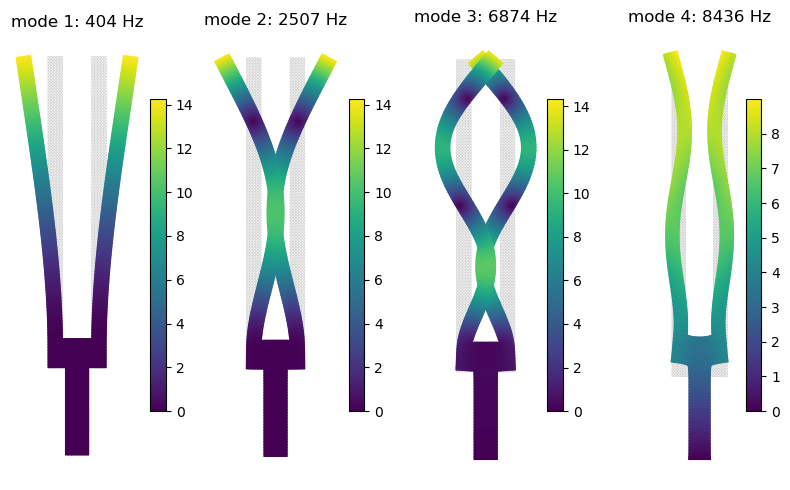

In [10]:
lam_0, modes_0 = eigenmodes(4)              # uniform fork
f_0 = frequencies(lam_0)

beta_L = np.array([1.8751, 4.6941, 7.8548])
f_beam = beta_L**2/(2*np.pi)*w_tine/L_tine**2*np.sqrt(E/(12*rho))
print("fork  [Hz]: " + "  ".join("%8.1f" % f for f in f_0))
print("beam  [Hz]: " + "  ".join("%8.1f" % f for f in f_beam) + "   (clamped cantilever tine)")
print("f2/f1:  fork %.3f,  beam %.3f,  target 6" % (f_0[1]/f_0[0], f_beam[1]/f_beam[0]))

pyplot.figure(figsize=(8, 5), dpi=100)
for k in range(4):
    pyplot.subplot(1, 4, k + 1)
    plot_fork(mode=modes_0[k], title='mode %d: %.0f Hz' % (k + 1, f_0[k]))
pyplot.tight_layout()
pyplot.savefig('fork-0.png')

sum rule, relative to lambda:  [5.75486507e-08 1.45343943e-09]
G delta:  formula              [ 1591.3820403  15539.82977793]
          finite difference    [ 1591.39894674 15540.05746782]


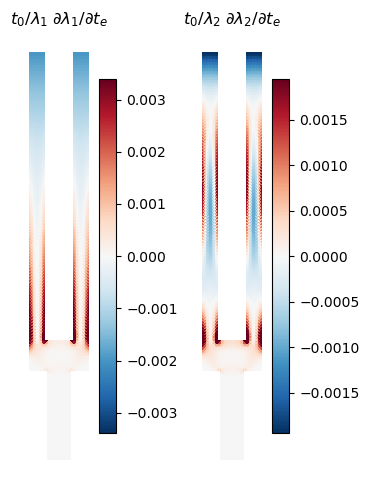

In [11]:
def sensitivity(lam_k, u_k):
    # d lambda_k / d t_e for every cell e (u_k normalised to u^T M u = 1)
    q = TestFunction(W)
    lam_k = Constant(lam_k)      # as a Constant, so that the form is compiled only once
    return assemble((inner(sigma_ps(u_k), epsilon(u_k)) - lam_k*rho*inner(u_k, u_k))*q*dx).get_local()

G = np.array([sensitivity(lam_0[k], modes_0[k]) for k in range(2)])

# check 1: sum_e t_e dlambda/dt_e = phi^T K phi - lambda phi^T M phi = 0
print("sum rule, relative to lambda: ", G @ t.vector().get_local()/lam_0[:2])

# check 2: central finite difference in a random direction
def eigenvalues_at(t_cells):
    t.vector()[:] = t_cells
    lam = eigenmodes(2)[0]
    t.vector()[:] = t0
    return lam

np.random.seed(0)
delta = 0.01*t0*np.random.uniform(-1.0, 1.0, W.dim())
print("G delta:  formula             ", G @ delta)
print("          finite difference   ", (eigenvalues_at(t0 + delta) - eigenvalues_at(t0 - delta))/2)

pyplot.figure(figsize=(4.5, 5), dpi=100)
for k in range(2):
    g = Function(W)
    g.vector()[:] = t0/lam_0[k]*G[k]         # dimensionless: relative change of lambda per relative change of t_e
    pyplot.subplot(1, 2, k + 1)
    plot_fork(field=g, title=r'$t_0/\lambda_%d\;\partial\lambda_%d/\partial t_e$' % (k + 1, k + 1),
              cmap='RdBu_r', symmetric=True)
pyplot.tight_layout()
pyplot.savefig('fork-1.png')

### 7. Tuning, and listening to the result

The Newton iteration converges in three steps. The tines become thinner (less mass) and the root of the tines
thicker (more stiffness). Finally the fork is struck: an impulse at the tip of a tine excites the $M$-normalised
modes with amplitudes $\varphi_{k,x}(\text{tip})^2$, and the tip velocity $\sum_k \varphi_{k,x}(\text{tip})^2\,
e^{-\zeta \omega_k \tau} \sin(\omega_k \tau)$ with a small modal damping $\zeta$ is written as a sound file, for the
uniform fork (out of tune, inharmonic clang) and for the tuned one (440 Hz with a harmonic overtone).

step    f1 [Hz]     f2 [Hz]    f2/f1   max |lam-lam*|/lam*   min t/t0  max t/t0
   0    404.313    2506.617   6.1997             1.6e-01     1.000     1.000
   1    441.391    2643.084   5.9881             6.3e-03     0.805     1.788
   2    440.004    2640.006   6.0000             1.9e-05     0.811     1.777
   3    440.000    2640.000   6.0000             6.7e-10     0.811     1.777


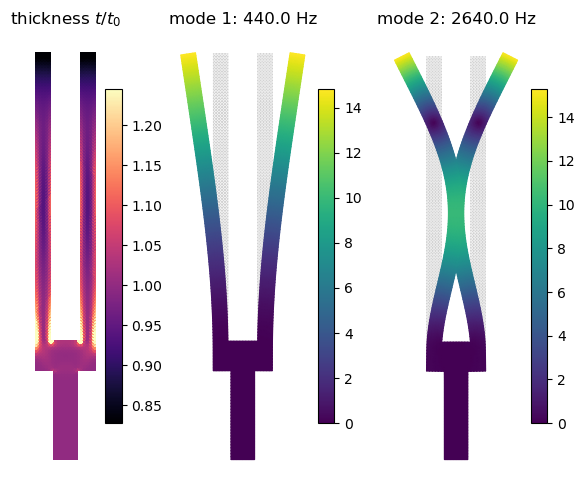

In [12]:
f_target   = np.array([440.0, 6*440.0])
lam_target = (2*np.pi*f_target)**2
t_min, t_max = 0.5*t0, 2.0*t0

t.vector()[:] = t0                         # start from the uniform fork
print("step    f1 [Hz]     f2 [Hz]    f2/f1   max |lam-lam*|/lam*   min t/t0  max t/t0")
for step in range(10):
    lam_f, modes_f = eigenmodes(2)
    t_cells  = t.vector().get_local()
    residual = lam_target - lam_f
    print("%4d  %9.3f  %10.3f  %7.4f  %18.1e  %8.3f  %8.3f"
          % (step, *frequencies(lam_f), np.sqrt(lam_f[1]/lam_f[0]), abs(residual/lam_target).max(),
             t_cells.min()/t0, t_cells.max()/t0))
    if abs(residual/lam_target).max() < 1e-9:
        break
    G = np.array([sensitivity(lam_f[k], modes_f[k]) for k in range(2)])
    delta_t = G.T @ np.linalg.solve(G @ G.T, residual)      # minimum-norm Newton step
    t.vector()[:] = np.clip(t_cells + delta_t, t_min, t_max)

t_rel = Function(W)
t_rel.vector()[:] = t.vector().get_local()/t0
pyplot.figure(figsize=(6.5, 5), dpi=100)
pyplot.subplot(1, 3, 1)
plot_fork(field=t_rel, title=r'thickness $t/t_0$', cmap='magma')
for k in range(2):
    pyplot.subplot(1, 3, k + 2)
    plot_fork(mode=modes_f[k], title='mode %d: %.1f Hz' % (k + 1, frequencies(lam_f)[k]))
pyplot.tight_layout()
pyplot.savefig('fork-2.png')

In [13]:
rate = 44100
tau  = np.arange(2*rate)/rate               # 2 seconds

def write_wav(filename, s):
    s = 0.8*s/abs(s).max()
    with wave.open(filename, 'w') as f:
        f.setnchannels(1)
        f.setsampwidth(2)
        f.setframerate(rate)
        f.writeframes((32767*s).astype(np.int16).tobytes())

def synthesise(filename, lam, modes, zeta=1.5e-4):
    tip   = Point(gap/2 + w_tine/2, y_top - h/2)
    omega = np.sqrt(lam)
    A     = np.array([u(tip)[0]**2 for u in modes])
    write_wav(filename, sum(A[k]*np.exp(-zeta*omega[k]*tau)*np.sin(omega[k]*tau) for k in range(len(lam))))
    print("%-16s" % filename + "  ".join("%7.1f Hz (%.2f)" % (fk, ak) for fk, ak in zip(frequencies(lam), A/A[0])))

from IPython.display import Audio, display
print("                 frequencies (relative amplitudes) of the modes")
synthesise('fork-before.wav', lam_0, modes_0)
synthesise('fork-after.wav', *eigenmodes(4))
display(Audio('fork-before.wav'))
display(Audio('fork-after.wav'))

                 frequencies (relative amplitudes) of the modes
fork-before.wav   404.3 Hz (1.00)   2506.6 Hz (0.95)   6874.2 Hz (0.88)   8435.7 Hz (0.03)
fork-after.wav    440.0 Hz (1.00)   2640.0 Hz (1.01)   7082.1 Hz (0.96)   8604.2 Hz (0.04)


## Exercises

### Exercise 1: The stability limit of forward Euler

For P1 elements on a uniform mesh with spacing $h$ the element matrices are
$K_e = \frac{\kappa}{h} \begin{pmatrix} 1 & -1 \\ -1 & 1 \end{pmatrix}$ and
$M_e = \frac{h}{6} \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix}$, lumped $M_e = \frac{h}{2} I$.

1. Show that the vectors $\varphi_j$ with the entries $(\varphi_j)_i = \sin(\theta_j i)$, $\theta_j = j \pi h$,
   solve $K \varphi = \lambda M \varphi$ at the inner nodes, and determine $\lambda_j$ for the lumped and for the
   consistent mass matrix. (Row $i$ of $K \varphi$ is $\frac{\kappa}{h}(-\varphi_{i-1} + 2\varphi_i - \varphi_{i+1})$,
   and $\sin(\theta (i \pm 1)) = \sin(\theta i) \cos\theta \pm \cos(\theta i) \sin\theta$.)
2. Which $j$ gives the largest eigenvalue, and what are $\lambda_{\max}$ and the stability limit
   $\Delta t \le 2 / \lambda_{\max}$ in both cases for $N \to \infty$?
3. Compute $\lambda_{\max}$ numerically for $N = 20$ with `scipy.linalg.eigh` (remove the two Dirichlet degrees of
   freedom) and confirm the limit with `solve_heat` and `forward_euler_lumped`: 200 steps with
   $\Delta t = 0.98 \cdot 2/\lambda_{\max}$ and with $1.02 \cdot 2/\lambda_{\max}$.

### Exercise 2: Heating through the end: how long until the steady state?

Problem 3 of lecture 1 as a time-dependent problem: $u(0) = 0$, no source, inflow $g = -1$ at $x = 1$,
$u_0 = 0$, $\kappa = 1$. Example 1 shows that the solution approaches the steady state $u = x$.

1. Separation of variables: show that
   $u(x, t) - x = -\sum_{k \ge 0} c_k \sin(\alpha_k x)\, e^{-\alpha_k^2 t}$ with $\alpha_k = (k + \tfrac12)\pi$
   satisfies the equation and all conditions if $c_k = 2 \int_0^1 x \sin(\alpha_k x) \, dx = 2 (-1)^k / \alpha_k^2$.
   Why $\alpha_k = (k + \tfrac12)\pi$, and not $k \pi$ as for problem 1?
2. The slowest mode decides how long the transient lasts. After which time $t^*$ is the deviation from the
   steady state below 1 % of the final value, $\max_x |u - x| < 0.01$? Compare with problem 1, whose slowest
   mode is $\sin(\pi x)\, e^{-\pi^2 t}$ with the coefficient $2/\pi$.
3. Verify with Crank–Nicolson, $\Delta t = 0.01$: print $\max_x |u(t) - x|$ at $t = 0.5, 1, 2, 3$ together with
   the first term of the series, and $t^*$ from the computation.

### Exercise 3: How many modes?

For the cantilever of examples 4 and 5:

1. The modes are $M$-orthonormal, $\Phi^T M \Phi = I$. What is $\Phi^T K \Phi$? Check both numerically for the
   first ten modes.
2. The initial deflection $U_0$ of example 5 has the strain energy $\tfrac12 U_0^T K U_0$ and the mass norm
   $U_0^T M U_0$. Express both through the modal coordinates $q_k(0)$ and the eigenfrequencies. How many modes are
   needed to capture 99 % of each?
3. A hammer blow at the tip instead: initial displacement zero and an impulse $P$ at the tip, i.e. $M \dot U(0) = P\, e_{\text{tip}}$.
   Which modal coordinates does it excite, and why does the truncation to a few modes work less well than in
   example 5? Plot the tip displacement over one period $T_1$ with 3, 10, 30 and all modes.